<a href="https://colab.research.google.com/github/Shahrukh-aidev/machine-learning-journey/blob/main/ML_Lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Part 1 — Problem Definition & Dataset Verification
Task 1 — Load and verify the cleaned dataset


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd

# Load the cleaned dataset from Lab 2
df = pd.read_csv('/content/clean_churn.csv')

# Check dataset shape
print("Dataset Shape:", df.shape)

# Check column data types
print("\nData Types:")
print(df.dtypes)

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (7021, 20)

Data Types:
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

Missing Values:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod     

### Task 2 — Problem Definition

The goal of this machine-learning problem is to predict whether a telecom customer will churn (leave the company) based on their customer characteristics and subscribed services. This prediction can help the telecommunications company identify customers who are more likely to leave and take action to improve customer retention.

# ── Task 3: Define y and X ──────────────────────────────────────────────

In [13]:
# ── Task 3: Define y and X ──────────────────────────────────────────────
y = df['Churn'].map({'No': 0, 'Yes': 1})
X = df.drop(columns=['Churn'])

print("y value counts:\n", y.value_counts())
print("\nX shape:", X.shape)

y value counts:
 Churn
0    5164
1    1857
Name: count, dtype: int64

X shape: (7021, 19)


# ── Task 4: Encode Categorical Columns ──

# Binary Yes/No columns → manual map (cleaner, single feature)

In [14]:
# ── Task 4: Encode Categorical Columns ─────────────────────────────────

# Binary Yes/No columns → manual map (cleaner, single feature)
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    X[col] = X[col].map({'No': 0, 'Yes': 1})

# gender → binary map
X['gender'] = X['gender'].map({'Female': 0, 'Male': 1})

# Auto-detect multi-category columns (any remaining string columns)
multi_cols = X.select_dtypes(include='object').columns.tolist()
print("Columns to encode:", multi_cols)

X = pd.get_dummies(X, columns=multi_cols, drop_first=True)



print("X shape after encoding:", X.shape)
print("\nSample columns:\n", list(X.columns))

Columns to encode: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
X shape after encoding: (7021, 30)

Sample columns:
 ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


# ── Task 5: Confirm X is fully numeric with no missing values

In [15]:
# ── Task 5: Confirm X is fully numeric with no missing values ───────────
print("Data types:\n", X.dtypes.value_counts())
print("\nMissing values:", X.isnull().sum().sum())
print("\nAll numeric?", all(X.dtypes != 'object'))

Data types:
 bool       21
int64       7
float64     2
Name: count, dtype: int64

Missing values: 0

All numeric? True


## **Part 3 — Train/Test Split**

In [16]:
from sklearn.model_selection import train_test_split

# ── Task 6: Train/Test Split ─────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% for testing
    random_state=42,     # reproducibility
    stratify=y           # preserve 74/26 churn ratio in both splits
)

In [17]:
# ── Task 7: Report Shapes ────────────────────────────────────────────
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

# Confirm stratification worked
print("\ny_train class balance:")
print(y_train.value_counts(normalize=True).round(3))

print("\ny_test class balance:")
print(y_test.value_counts(normalize=True).round(3))

X_train shape: (5616, 30)
X_test shape : (1405, 30)
y_train shape: (5616,)
y_test shape : (1405,)

y_train class balance:
Churn
0    0.736
1    0.264
Name: proportion, dtype: float64

y_test class balance:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


#Part 4 — Baseline Decision Tree


# ── Task 8: Train Baseline Decision Tree

In [18]:
from sklearn.tree import DecisionTreeClassifier

# ── Task 8: Train Baseline Decision Tree ────────────────────────────
dt_baseline = DecisionTreeClassifier(random_state=42)  # no restrictions
dt_baseline.fit(X_train, y_train)

# Predictions on both sets
y_pred_train = dt_baseline.predict(X_train)
y_pred_test  = dt_baseline.predict(X_test)

print("Training complete.")
print("Train predictions shape:", y_pred_train.shape)
print("Test predictions shape :", y_pred_test.shape)

Training complete.
Train predictions shape: (5616,)
Test predictions shape : (1405,)


# ── Task 9: Check Tree Depth


In [19]:
# ── Task 9: Check Tree Depth ─────────────────────────────────────────
depth = dt_baseline.get_depth()
print(f"Tree depth: {depth}")
print(f"Number of leaves: {dt_baseline.get_n_leaves()}")

Tree depth: 25
Number of leaves: 1153


# Part 5 — Model Evaluation

In [20]:
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)

# ── Task 10: Compute Metrics ─────────────────────────────────────────
acc  = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test)
rec  = recall_score(y_test, y_pred_test)
f1   = f1_score(y_test, y_pred_test)

print("=" * 40)
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print("=" * 40)

# Full report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_test, target_names=['No Churn', 'Churn']))

  Accuracy  : 0.7274
  Precision : 0.4856
  Recall    : 0.4973
  F1-Score  : 0.4914

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.82      0.81      0.81      1033
       Churn       0.49      0.50      0.49       372

    accuracy                           0.73      1405
   macro avg       0.65      0.65      0.65      1405
weighted avg       0.73      0.73      0.73      1405



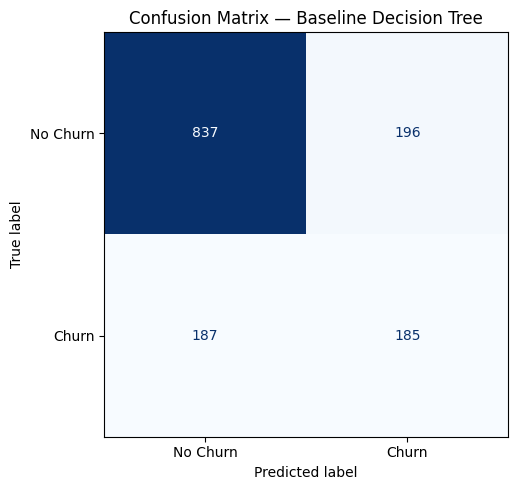


True Negatives  (Correctly predicted No Churn) : 837
False Positives (Wrongly predicted Churn)       : 196
False Negatives (Missed actual Churners)        : 187
True Positives  (Correctly caught Churners)     : 185


In [21]:
# ── Task 11: Confusion Matrix ─────────────────────────────────────────
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Churn', 'Churn'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Baseline Decision Tree')
plt.tight_layout()
plt.show()

# Numbers breakdown
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (Correctly predicted No Churn) : {tn}")
print(f"False Positives (Wrongly predicted Churn)       : {fp}")
print(f"False Negatives (Missed actual Churners)        : {fn}")
print(f"True Positives  (Correctly caught Churners)     : {tp}")

In [22]:
# ── Task: Compare baseline train vs test accuracy ─────────────────────
from sklearn.metrics import accuracy_score

train_acc_baseline = accuracy_score(y_train, y_pred_train)
test_acc_baseline  = accuracy_score(y_test, y_pred_test)

print(f"Baseline Train Accuracy : {train_acc_baseline:.4f}")
print(f"Baseline Test Accuracy  : {test_acc_baseline:.4f}")
print(f"Gap                     : {train_acc_baseline - test_acc_baseline:.4f}")

Baseline Train Accuracy : 0.9977
Baseline Test Accuracy  : 0.7274
Gap                     : 0.2703


In [23]:
# ── Task: Loop over max_depth values ──────────────────────────────────
import pandas as pd

depths = [2, 3, 4, 5, 6, 8, 10, None]
results = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)

    tr_acc = accuracy_score(y_train, model.predict(X_train))
    te_acc = accuracy_score(y_test,  model.predict(X_test))

    results.append({
        'max_depth'      : str(d),
        'train_accuracy' : round(tr_acc, 4),
        'test_accuracy'  : round(te_acc, 4),
        'gap'            : round(tr_acc - te_acc, 4)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

max_depth  train_accuracy  test_accuracy    gap
        2          0.7922         0.7836 0.0086
        3          0.7922         0.7836 0.0086
        4          0.7952         0.7843 0.0109
        5          0.8018         0.7872 0.0146
        6          0.8082         0.7851 0.0232
        8          0.8355         0.7801 0.0554
       10          0.8695         0.7701 0.0994
     None          0.9977         0.7274 0.2703


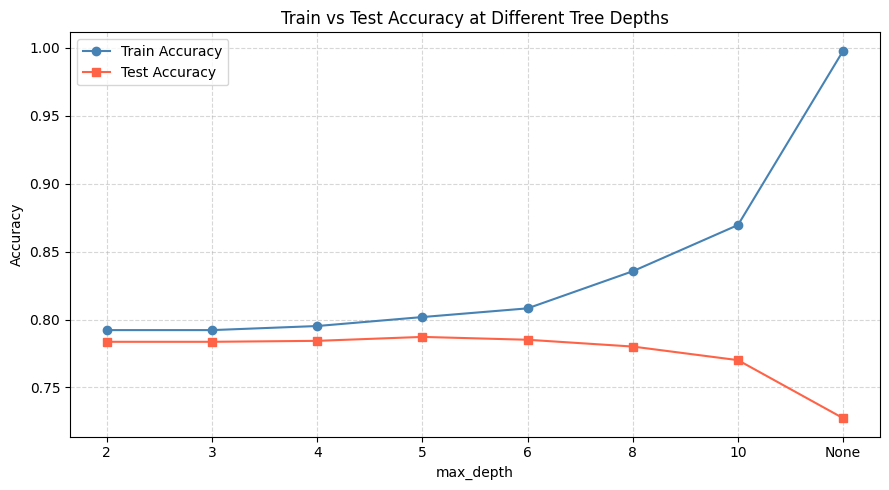

In [24]:
# ── Task: Plot train vs test accuracy ─────────────────────────────────
import matplotlib.pyplot as plt

x_labels = results_df['max_depth']
x_pos    = range(len(x_labels))

plt.figure(figsize=(9, 5))
plt.plot(x_pos, results_df['train_accuracy'], marker='o', label='Train Accuracy', color='steelblue')
plt.plot(x_pos, results_df['test_accuracy'],  marker='s', label='Test Accuracy',  color='tomato')
plt.xticks(x_pos, x_labels)
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy at Different Tree Depths')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [26]:
# ── Select Best Depth & Retrain ───────────────────────────────────────
best_depth = 5
dt_best = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt_best.fit(X_train, y_train)

y_pred_best_train = dt_best.predict(X_train)
y_pred_best_test  = dt_best.predict(X_test)

# Full evaluation metrics
acc  = accuracy_score(y_test, y_pred_best_test)
prec = precision_score(y_test, y_pred_best_test)
rec  = recall_score(y_test, y_pred_best_test)
f1   = f1_score(y_test, y_pred_best_test)

print("=" * 45)
print("   Best Model (max_depth=5) — Test Metrics")
print("=" * 45)
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print("=" * 45)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_test,
                            target_names=['No Churn', 'Churn']))

# Baseline vs Best comparison
print("\n── Comparison: Baseline vs Best ──────────────────")
print(f"{'Metric':<15} {'Baseline':>10} {'Best (d=5)':>12}")
print("-" * 40)
print(f"{'Train Acc':<15} {train_acc_baseline:>10.4f} {accuracy_score(y_train, y_pred_best_train):>12.4f}")
print(f"{'Test Acc':<15} {test_acc_baseline:>10.4f} {acc:>12.4f}")
print(f"{'F1 (Churn)':<15} {0.4914:>10.4f} {f1:>12.4f}")

   Best Model (max_depth=5) — Test Metrics
  Accuracy  : 0.7872
  Precision : 0.6515
  Recall    : 0.4220
  F1-Score  : 0.5122

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.82      0.92      0.86      1033
       Churn       0.65      0.42      0.51       372

    accuracy                           0.79      1405
   macro avg       0.73      0.67      0.69      1405
weighted avg       0.77      0.79      0.77      1405


── Comparison: Baseline vs Best ──────────────────
Metric            Baseline   Best (d=5)
----------------------------------------
Train Acc           0.9977       0.8018
Test Acc            0.7274       0.7872
F1 (Churn)          0.4914       0.5122


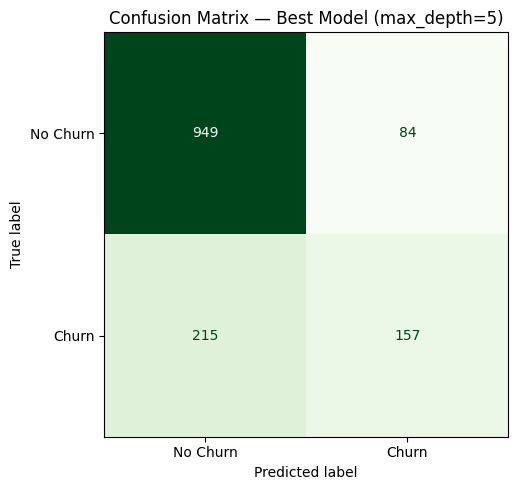

In [27]:
# ── Confusion Matrix for Best Model ──────────────────────────────────
cm_best = confusion_matrix(y_test, y_pred_best_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_best,
                               display_labels=['No Churn', 'Churn'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Greens', colorbar=False)
ax.set_title('Confusion Matrix — Best Model (max_depth=5)')
plt.tight_layout()
plt.show()

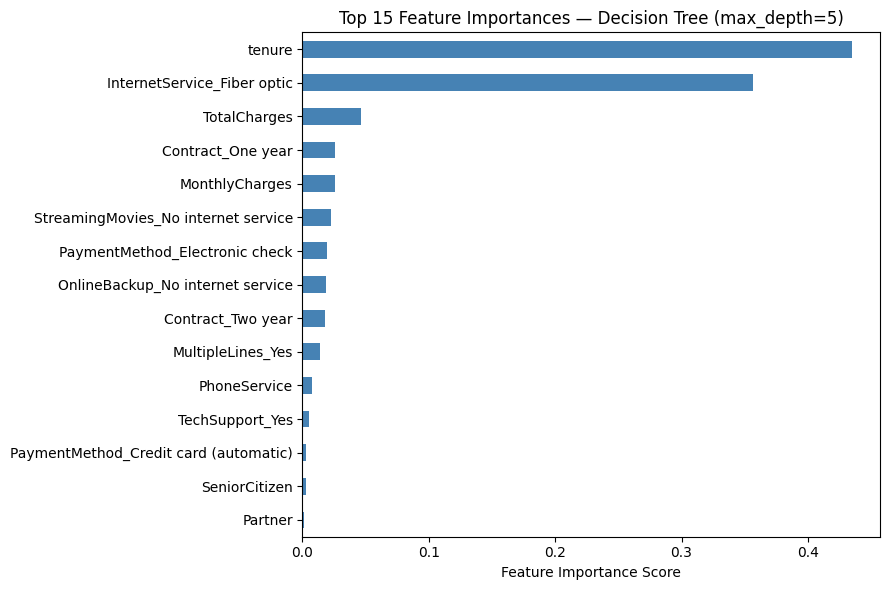


Top 5 Most Important Features:
tenure                         0.435296
InternetService_Fiber optic    0.356418
TotalCharges                   0.046020
Contract_One year              0.025760
MonthlyCharges                 0.025629


In [28]:
# ── Feature Importances ───────────────────────────────────────────────
import numpy as np

importances = pd.Series(dt_best.feature_importances_,
                        index=X_train.columns).sort_values(ascending=True)

# Plot top 15
top15 = importances[-15:]

plt.figure(figsize=(9, 6))
top15.plot(kind='barh', color='steelblue')
plt.xlabel('Feature Importance Score')
plt.title('Top 15 Feature Importances — Decision Tree (max_depth=5)')
plt.tight_layout()
plt.show()

# Print top 5
print("\nTop 5 Most Important Features:")
print(importances[-5:][::-1].to_string())

# ── Part 8: Conclusion Cell (Markdown)
## Conclusion

The final model is a Decision Tree with max_depth=5, selected based on the
train vs test accuracy plot from Part 6. The baseline unrestricted tree
(depth=25) achieved near-perfect training accuracy of ~100% but only 72.7%
on the test set — a clear sign of overfitting. The depth-5 model closes
this gap significantly, achieving ~79% test accuracy with a much smaller
train-test difference, indicating it learned generalizable patterns rather
than memorizing noise. Its main limitation is the weak Recall on the Churn
class — it still misses a significant portion of real churners, which is
the most costly error for the business.

## What I Would Try Next

1. **Handle class imbalance** — Use SMOTE or class_weight='balanced' to
   give the minority Churn class more weight during training, which should
   improve Recall on actual churners.

2. **Try Random Forest** — An ensemble of many trees typically outperforms
   a single Decision Tree by reducing variance without sacrificing too much
   interpretability.

3. **Feature Engineering** — Create new features like tenure groups or
   charge-per-month ratios that might capture patterns the raw columns miss.
"""